In [111]:
from pydantic import BaseModel
from langgraph.graph import StateGraph, START, END

In [112]:
class GreetState(BaseModel):
    message: str = ""

In [113]:
graph = StateGraph(GreetState)

In [114]:
### Node - Python Functions

In [115]:
def Greet(state:GreetState):
    state.message = f"{state.message} . All Good ! "
    return state
  

def upperCase(state:GreetState):
    state.message = state.message.upper()
    return state

In [116]:
graph.add_node("greet", Greet)

In [117]:
graph.add_node("upper_case", upperCase)

In [118]:
graph.add_edge(START, "greet")
graph.add_edge("greet", "upper_case")
graph.add_edge("upper_case", END)

In [119]:
finalGraph = graph.compile()

In [120]:
res = finalGraph.invoke({"message":"I am learning langgraph"})

In [121]:
res

{'message': 'I AM LEARNING LANGGRAPH . ALL GOOD ! '}

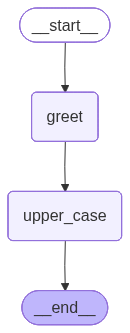

In [122]:
from IPython.display import Image
Image(finalGraph.get_graph().draw_mermaid_png())